In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_auc_score

df = pd.read_csv("Customer-Churn-Records.csv")

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [4]:
df.shape

(10000, 18)

In [5]:
print("\nDataset information:")
print(df.info())


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-nu

In [6]:
print("\nSummary statistics:")
print(df.describe())


Summary statistics:
         RowNumber    CustomerId   CreditScore           Age        Tenure  \
count  10000.00000  1.000000e+04  10000.000000  10000.000000  10000.000000   
mean    5000.50000  1.569094e+07    650.528800     38.921800      5.012800   
std     2886.89568  7.193619e+04     96.653299     10.487806      2.892174   
min        1.00000  1.556570e+07    350.000000     18.000000      0.000000   
25%     2500.75000  1.562853e+07    584.000000     32.000000      3.000000   
50%     5000.50000  1.569074e+07    652.000000     37.000000      5.000000   
75%     7500.25000  1.575323e+07    718.000000     44.000000      7.000000   
max    10000.00000  1.581569e+07    850.000000     92.000000     10.000000   

             Balance  NumOfProducts    HasCrCard  IsActiveMember  \
count   10000.000000   10000.000000  10000.00000    10000.000000   
mean    76485.889288       1.530200      0.70550        0.515100   
std     62397.405202       0.581654      0.45584        0.499797   
min 

In [7]:
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64


In [8]:
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0,0,1,DIAMOND,300
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,0,5,PLATINUM,771
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1,1,3,SILVER,564
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,1,2,GOLD,339


In [9]:
print("\nTarget Variable conversion:")
print(df["Exited"].value_counts())


Target Variable conversion:
Exited
0    7962
1    2038
Name: count, dtype: int64


In [10]:
X = df.drop(columns=["Exited", "Surname", "RowNumber", "CustomerId"])
y = df["Exited"]

In [11]:
X_encoded = pd.get_dummies(X,
columns=["Geography", "Gender", "Card Type"], drop_first=True, dtype=int
)

In [12]:
print("\nShape after encoding:")
print(X_encoded.shape)


Shape after encoding:
(10000, 17)


In [13]:
print("\nFirst few encoded columns:")
print(X_encoded.head())


First few encoded columns:
   CreditScore  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0          619   42       2       0.00              1          1   
1          608   41       1   83807.86              1          0   
2          502   42       8  159660.80              3          1   
3          699   39       1       0.00              2          0   
4          850   43       2  125510.82              1          1   

   IsActiveMember  EstimatedSalary  Complain  Satisfaction Score  \
0               1        101348.88         1                   2   
1               1        112542.58         1                   3   
2               0        113931.57         1                   3   
3               0         93826.63         0                   5   
4               1         79084.10         0                   5   

   Point Earned  Geography_Germany  Geography_Spain  Gender_Male  \
0           464                  0                0            0   
1           456   

In [14]:
# Train-Test-Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded,
y,
test_size = 0.20,
random_state = 42,
stratify = y)

In [16]:
print("\nTraining set shape:")
print(X_train.shape)


Training set shape:
(8000, 17)


In [17]:
print("\nTesting set shape:")
print(X_test.shape)


Testing set shape:
(2000, 17)


In [18]:
# Scale the data

In [19]:
scaler = StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [20]:
import sys

print(sys.executable)

/usr/bin/python3


In [21]:
!{sys.executable} -m pip install imbalanced-learn

In [22]:
from imblearn.over_sampling import SMOTE

print("SMOTE installed successfully!")

SMOTE installed successfully!


In [23]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train)

# Feature Engineering

In [24]:
# AgeGroup
def create_age_group(age):
    if age < 30:
        return "Young"
    elif age < 45:
        return "Adult"
    elif age < 60:
        return "Middle-aged"
    else:
        return "Senior"

df["AgeGroup"] = df["Age"].apply(create_age_group)

df[["Age", "AgeGroup"]].head(10)

,Age,AgeGroup
0,42,Adult
1,41,Adult
2,42,Adult
3,39,Adult
4,43,Adult
5,44,Adult
6,50,Middle-aged
7,29,Young
8,44,Adult
9,27,Young


In [25]:
# Engaged
df["EngagementRisk"] = (
    (df["IsActiveMember"] == 0).astype(int)
    + (df["NumOfProducts"] <= 1).astype(int)
    + (df["Complain"] == 1).astype(int)
)

df[["IsActiveMember", "EngagementRisk"]].head(10)

,IsActiveMember,EngagementRisk
0,1,2
1,1,2
2,0,2
3,0,1
4,1,1
5,0,2
6,1,0
7,0,2
8,1,0
9,1,1


In [26]:
# Tenure_Age_Ratio
df["Tenure_Age_Ratio"] = (
    df["Tenure"] / df["Age"].replace(0, np.nan)
)

df[["Tenure", "Tenure_Age_Ratio"]].head(10)

,Tenure,Tenure_Age_Ratio
0,2,0.047619
1,1,0.024390
2,8,0.190476
3,1,0.025641
4,2,0.046512
5,8,0.181818
6,7,0.140000
7,4,0.137931
8,4,0.090909
9,2,0.074074


In [27]:
# Balance_Salary_Ratio
df["Balance_Salary_Ratio"] = (
    df["Balance"] /
    df["EstimatedSalary"].replace(0, np.nan)
)

df[["Balance", "Balance_Salary_Ratio"]].head(10)

,Balance,Balance_Salary_Ratio
0,0.00,0.000000
1,83807.86,0.744677
2,159660.80,1.401375
3,0.00,0.000000
4,125510.82,1.587055
5,113755.78,0.759604
6,0.00,0.000000
7,115046.74,0.963969
8,142051.07,1.895518
9,134603.88,1.876647


In [28]:
# ZeroBalance
df["ZeroBalance"] = (df["Balance"] == 0).astype(int)
df[["Balance", "ZeroBalance"]].head(10)

,Balance,ZeroBalance
0,0.00,1
1,83807.86,0
2,159660.80,0
3,0.00,1
4,125510.82,0
5,113755.78,0
6,0.00,1
7,115046.74,0
8,142051.07,0
9,134603.88,0


# Model 1 - Logistic Regression

In [29]:
# Build and train logistic regression model

In [30]:
model = LogisticRegression(max_iter = 1000,
                           random_state = 42)

In [31]:
model.fit(X_train_scaled, y_train)
print("\nModel training completed.")


Model training completed.


In [32]:
# Genereate predictions

In [33]:
y_pred_logistic = model.predict(X_test_scaled)
y_prob_logistic = model.predict_proba(X_test_scaled)[:,1]

In [34]:
print("\nFirst 10 predicted classes:")
print(y_pred_logistic[:10])


First 10 predicted classes:
[0 0 0 1 0 1 1 0 0 0]


In [35]:
print("\nFirst 10 predicted probabilities:")
print(y_prob_logistic[:10])


First 10 predicted probabilities:
[1.04164122e-04 1.04258568e-03 3.15380171e-04 9.97784436e-01
 1.05621017e-03 9.93181196e-01 9.93410448e-01 1.02488936e-03
 2.01293283e-04 4.77825712e-04]


In [36]:
# Understand probabilities

In [37]:
probability_examples = pd.DataFrame({
    "Actual Outcomes": y_test.values[:10],
    "Predicted Probability": y_prob_logistic[:10],
    "Predicted Class": y_pred_logistic[:10]
})

print("\nProbability examples:")
print(probability_examples)


Probability examples:
   Actual Outcomes  Predicted Probability  Predicted Class
0                0               0.000104                0
1                0               0.001043                0
2                0               0.000315                0
3                1               0.997784                1
4                0               0.001056                0
5                1               0.993181                1
6                1               0.993410                1
7                0               0.001025                0
8                0               0.000201                0
9                0               0.000478                0


# Model Evaluation

In [38]:
accuracy = accuracy_score(y_test, y_pred_logistic)
precision = precision_score(y_test, y_pred_logistic)
recall = recall_score(y_test, y_pred_logistic)
f1 = f1_score(y_test, y_pred_logistic)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9985
Precision: 0.9975429975429976
Recall   : 0.9950980392156863
F1 Score : 0.996319018404908


In [39]:
cm_logistic = confusion_matrix(y_test, y_pred_logistic)
print("Confusion Matrix:", cm_logistic)

Confusion Matrix: [[1591    1]
 [   2  406]]


In [40]:
cp_logistic = classification_report(y_test, y_pred_logistic)
print("Classification Report:", cp_logistic)

Classification Report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1592
           1       1.00      1.00      1.00       408

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



# Model 2 - Random Forest

In [41]:
# Build and train a Random Forest Model

In [42]:
from sklearn.ensemble import RandomForestClassifier

In [43]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [44]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [45]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Model Evaluation

In [46]:
print("Random Forest Results")
print("---------------------")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

Random Forest Results
---------------------
Accuracy : 0.9985
Precision: 0.9975429975429976
Recall   : 0.9950980392156863
F1 Score : 0.996319018404908


In [47]:
print("Logistic first 10 predictions:")
print(y_pred_logistic[:10])

print("\nRandom Forest first 10 predictions:")
print(y_pred_rf[:10])

print("\nLogistic first 10 probabilities:")
print(y_prob_logistic[:10])

print("\nRandom Forest first 10 probabilities:")
print(y_prob_rf[:10])

print("\nDifferent classifications:",
      (y_pred_logistic != y_pred_rf).sum())

Logistic first 10 predictions:
[0 0 0 1 0 1 1 0 0 0]

Random Forest first 10 predictions:
[0 0 0 1 0 1 1 0 0 0]

Logistic first 10 probabilities:
[1.04164122e-04 1.04258568e-03 3.15380171e-04 9.97784436e-01
 1.05621017e-03 9.93181196e-01 9.93410448e-01 1.02488936e-03
 2.01293283e-04 4.77825712e-04]

Random Forest first 10 probabilities:
[0.   0.   0.01 0.99 0.   0.98 0.97 0.   0.   0.  ]

Different classifications: 0


## Used the code above to verify whether my predications for the Logistic Regression model and the Random Forest model are identical. Turns out they are identical as the differance in classification returned = 0.

In [48]:
print("Different predictions:",
      (y_pred_logistic != y_pred_rf).sum())

print("Logistic prediction counts:")
print(pd.Series(y_pred_logistic).value_counts())

print("\nRandom Forest prediction counts:")
print(pd.Series(y_pred_rf).value_counts())

Different predictions: 0
Logistic prediction counts:
0    1593
1     407
Name: count, dtype: int64

Random Forest prediction counts:
0    1593
1     407
Name: count, dtype: int64


In [49]:
print("LOGISTIC REGRESSION")
print("Accuracy:", accuracy_score(y_test, y_pred_logistic))
print("Precision:", precision_score(y_test, y_pred_logistic))
print("Recall:", recall_score(y_test, y_pred_logistic))
print("F1:", f1_score(y_test, y_pred_logistic))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_logistic))

print("\nRANDOM FOREST")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

LOGISTIC REGRESSION
Accuracy: 0.9985
Precision: 0.9975429975429976
Recall: 0.9950980392156863
F1: 0.996319018404908
ROC-AUC: 0.9992425362104641

RANDOM FOREST
Accuracy: 0.9985
Precision: 0.9975429975429976
Recall: 0.9950980392156863
F1: 0.996319018404908
ROC-AUC: 0.9980978729431471


## The models aren't exactly the same because their probabilities differ. At the default threshold of 0.5, they are simply making the same choices. Hence the introduction of ROC-AUC as it evaluates how well the models rank churners above non-churners, using the probabilities rather than just the final 0/1 classification.

In [50]:
print("Are the probabilities identical?",
      (y_prob_logistic == y_prob_rf).all())

print("Mean absolute probability difference:",
      abs(y_prob_logistic - y_prob_rf).mean())

Are the probabilities identical? False
Mean absolute probability difference: 0.009336740202499787


## The code above confirms that the models are genuinely producing different probability estimates.

In [51]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:", cm_rf)

Confusion Matrix: [[1591    1]
 [   2  406]]


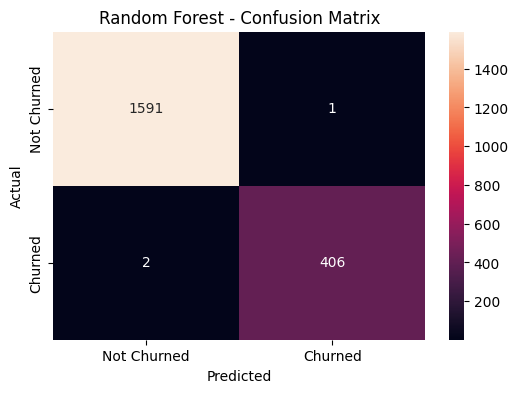

In [52]:
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    xticklabels=["Not Churned", "Churned"],
    yticklabels=["Not Churned", "Churned"]
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [53]:
cp_rf = classification_report(y_test, y_pred_rf)
print("Classification Report:", cp_rf)

Classification Report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1592
           1       1.00      1.00      1.00       408

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



# Performance for Model 1 - Logitisc Regression

In [54]:
y_prob_logistic1 = model.predict_proba(X_test_scaled)[:, 1]

auc_model1 = roc_auc_score(y_test, y_prob_logistic1)

print("Model 1 ROC-AUC:", auc_model1)

Model 1 ROC-AUC: 0.9992425362104641
